# Collecte de Données — Tier 3 : Diversification Avancée
## Projet ValuSense — Sources Institutionnelles & Augmentation par Perturbation

**Objectif :** Maximiser la diversité et le réalisme du dataset en ajoutant :
1. **SEC EDGAR XBRL** — déclarations réelles de juste valeur (IFRS/GAAP Level 1/2/3) extraites des bilans 10-K
2. **Banque Mondiale** — données souveraines (dette, notation, spreads) pour renforcer les classes Bond et Credit-Model
3. **BIS** — statistiques OTC sur les dérivés mondiaux (swaps, forwards, options) pour calibrer les profils Derivative
4. **Augmentation par perturbation** — variations contrôlées aux frontières de décision pour renforcer la robustesse du modèle

**Prérequis :** Avoir exécuté `02b_data_augmentation.ipynb` (Tier 1) et `02c_tier2_collection.ipynb` (Tier 2)


---
## 0. Configuration


In [9]:
import pandas as pd
import numpy as np
import requests
import time
import os
import warnings
from pathlib import Path
from io import StringIO
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from tqdm import tqdm

warnings.filterwarnings("ignore")
np.random.seed(42)

DATA_ROOT = Path("data_valuation_project")
for d in ["raw/sec_edgar", "raw/worldbank", "raw/bis", "processed"]:
    (DATA_ROOT / d).mkdir(parents=True, exist_ok=True)

# Charger le dataset Tier 2 comme base
tier2_path = DATA_ROOT / "processed/labeled_valuation_dataset_tier2.csv"
if tier2_path.exists():
    df_base = pd.read_csv(tier2_path)
    print(f"Base Tier 2 : {len(df_base):,} lignes")
else:
    # Fallback sur l'augmenté Tier 1 ou l'original
    for fallback in ["labeled_valuation_dataset_augmented.csv", "labeled_valuation_dataset.csv"]:
        p = DATA_ROOT / "processed" / fallback
        if p.exists():
            df_base = pd.read_csv(p)
            print(f"Fallback sur {fallback} : {len(df_base):,} lignes")
            break

COLUMNS = list(df_base.columns)
print(f"Schema : {COLUMNS}")
print(f"Distribution actuelle :")
print(df_base["recommended_method"].value_counts().to_string())

Base Tier 2 : 9,735 lignes
Schema : ['asset_class', 'asset_subclass', 'has_market_price', 'has_cash_flows', 'has_options_features', 'is_exchange_traded', 'liquidity', 'maturity_years', 'has_credit_risk', 'has_early_exercise', 'is_path_dependent', 'data_availability', 'volatility_available', 'ifrs_level', 'recommended_method']
Distribution actuelle :
recommended_method
DCF                3165
Black-Scholes      1360
Cost-of-Carry      1273
Credit-Model       1071
Forward-Pricing     982
Monte-Carlo         964
Binomial-Tree       858
DDM                  24
Mark-to-Market       20
Relative             18


---
## 1. SEC EDGAR — Déclarations de Juste Valeur (Fair Value Disclosures)

Les entreprises cotées aux USA publient dans leurs 10-K la répartition de leurs actifs financiers selon les **niveaux de juste valeur** (ASC 820, équivalent IFRS 13) :
- **Level 1** : prix cotés sur marchés actifs
- **Level 2** : inputs observables indirects
- **Level 3** : inputs non observables (modèles internes)

Ces données constituent une **source de labels implicites réels** : si une entreprise déclare ses obligations corporate en Level 2, cela valide notre mapping Bond → DCF avec IFRS Level 2.

L'API EDGAR est **gratuite**, nécessite uniquement un User-Agent avec email.


In [10]:
# ── Configuration EDGAR ────────────────────────────────────────
SEC_BASE = "https://data.sec.gov"
SEC_EFTS = "https://efts.sec.gov/LATEST"

# OBLIGATOIRE : renseigner un email valide (politique SEC)
USER_AGENT = "oumayma.mrabet07@gmail.com"
SEC_HEADERS = {"User-Agent": USER_AGENT, "Accept-Encoding": "gzip, deflate"}


def sec_get(url, params=None):
    # GET avec gestion du rate limit SEC.
    try:
        r = requests.get(url, headers=SEC_HEADERS, params=params, timeout=15)
        time.sleep(0.15)  # respecter 10 req/sec
        if r.status_code == 200:
            return r.json() if "json" in r.headers.get("Content-Type", "") else r.text
        else:
            print(f"    SEC erreur {r.status_code}: {url}")
            return None
    except Exception as e:
        print(f"    SEC exception: {e}")
        return None


print("Client SEC EDGAR pret.")
print(f"User-Agent : {USER_AGENT}")

Client SEC EDGAR pret.
User-Agent : oumayma.mrabet07@gmail.com


In [11]:
# ── Récupérer les filings récents avec fair value disclosures ──
# On cible les 10-K des grandes entreprises financières (banques, assurances)
# car elles détiennent les portefeuilles d'actifs les plus diversifiés

TARGET_CIKS = {
    # Banques majeures (portefeuilles obligataires et dérivés massifs)
    "0000019617": "JPMorgan Chase",
    "0000070858": "Bank of America",
    "0000072971": "Wells Fargo",
    "0000886982": "Goldman Sachs",
    "0000895421": "Morgan Stanley",
    "0000831001": "Citigroup",

    # Assurances (portefeuilles obligataires Level 2/3)
    "0000820081": "MetLife",
    "0000005272":  "AIG",
    "0000049196": "Prudential Financial",

    # Asset Managers
    "0001364742": "BlackRock",
    "0000091142": "State Street",

    # Tech (trésorerie investie en obligations)
    "0000320193": "Apple",
    "0000789019": "Microsoft",
    "0001652044": "Alphabet",
    "0001018724": "Amazon",
}


def fetch_company_facts(cik):
    # Telecharge les company facts XBRL pour un CIK donne.
    cik_padded = cik.lstrip("0").zfill(10)
    url = f"{SEC_BASE}/api/xbrl/companyfacts/CIK{cik_padded}.json"
    return sec_get(url)


# ── Extraire les tags liés à la juste valeur ──────────────────
FAIR_VALUE_TAGS = [
    # ASC 820 / IFRS 13 fair value hierarchy
    "FairValueMeasuredOnRecurringBasisLevel1",
    "FairValueMeasuredOnRecurringBasisLevel2",
    "FairValueMeasuredOnRecurringBasisLevel3",
    "AssetsFairValueDisclosure",
    "LiabilitiesFairValueDisclosure",
    "FairValueAssetsAndLiabilitiesMeasuredOnRecurringBasis",
    # Investissements par catégorie
    "AvailableForSaleSecurities",
    "AvailableForSaleSecuritiesDebtSecurities",
    "HeldToMaturitySecurities",
    "TradingSecurities",
    "DerivativeAssets",
    "DerivativeLiabilities",
    "DerivativeNotionalAmount",
]


def extract_fair_value_data(facts, company_name):
    # Extrait les donnees de juste valeur des company facts XBRL.
    rows = []
    if not facts or "facts" not in facts:
        return rows

    # Chercher dans us-gaap et ifrs-full
    for taxonomy in ["us-gaap", "ifrs-full"]:
        if taxonomy not in facts["facts"]:
            continue

        for tag in FAIR_VALUE_TAGS:
            if tag not in facts["facts"][taxonomy]:
                continue

            units = facts["facts"][taxonomy][tag].get("units", {})
            for unit_type, entries in units.items():
                if unit_type != "USD":
                    continue
                # Prendre les 3 dernières déclarations annuelles
                annual = [e for e in entries if e.get("form") in ["10-K", "20-F"]]
                annual.sort(key=lambda x: x.get("end", ""), reverse=True)

                for entry in annual[:3]:
                    rows.append({
                        "company": company_name,
                        "tag": tag,
                        "value_usd": entry.get("val"),
                        "period_end": entry.get("end"),
                        "form": entry.get("form"),
                        "filed": entry.get("filed"),
                    })

    return rows


# ── Collecter ─────────────────────────────────────────────────
print("Collecte SEC EDGAR en cours...")
print(f"{'Entreprise':<25} {'Tags trouves':>12}")
print("-" * 40)

all_fv_data = []
for cik, name in TARGET_CIKS.items():
    facts = fetch_company_facts(cik)
    rows = extract_fair_value_data(facts, name)
    all_fv_data.extend(rows)
    print(f"  {name:<23} {len(rows):>12}")
    time.sleep(0.2)

df_edgar = pd.DataFrame(all_fv_data)
if not df_edgar.empty:
    df_edgar.to_csv(DATA_ROOT / "raw/sec_edgar/fair_value_disclosures.csv", index=False)
    print(f"\nTotal : {len(df_edgar)} entrees, {df_edgar['company'].nunique()} entreprises")
    print(f"\nTags les plus frequents :")
    print(df_edgar["tag"].value_counts().head(10).to_string())
else:
    print("\nAucune donnee EDGAR recuperee.")

Collecte SEC EDGAR en cours...
Entreprise                Tags trouves
----------------------------------------
  JPMorgan Chase                    18
  Bank of America                   15
  Wells Fargo                       18
  Goldman Sachs                     26
  Morgan Stanley                    12
  Citigroup                         18
  MetLife                            0
  AIG                               15
  Prudential Financial              21
  BlackRock                         18
  State Street                       3
  Apple                              6
  Microsoft                         15
  Alphabet                           9
  Amazon                             2

Total : 196 entrees, 14 entreprises

Tags les plus frequents :
tag
AvailableForSaleSecuritiesDebtSecurities    38
DerivativeLiabilities                       30
DerivativeAssets                            30
AvailableForSaleSecurities                  29
HeldToMaturitySecurities                    24
T

### 1.1 Conversion EDGAR → Lignes Labellisées

Les déclarations de juste valeur nous permettent de créer des profils d'actifs **implicitement labellisés** : un actif déclaré en Level 1 avec prix observable → Mark-to-Market, un dérivé en Level 3 → Monte-Carlo ou DCF.


In [12]:
def edgar_to_labeled(df_edgar):
    # Convertit les donnees EDGAR en lignes labellisees.
    rows = []
    if df_edgar.empty:
        return pd.DataFrame()

    for _, r in df_edgar.iterrows():
        tag = str(r.get("tag", "")).lower()
        val = r.get("value_usd", 0)
        if val is None or val <= 0:
            continue

        # Level 1 → Mark-to-Market (actifs liquides cotés)
        if "level1" in tag:
            rows.append(_make_row(
                "Equity", "Blue Chip (Liquid)", "Mark-to-Market",
                has_mp=1, has_cf=1, exchange=1, vol=1,
                liq="High", data="Full", ifrs=1
            ))
            # Aussi des obligations gouvernementales Level 1
            rows.append(_make_row(
                "Bond", "Government Bond", "DCF",
                has_mp=1, has_cf=1, exchange=1, vol=1,
                liq="High", data="Full", ifrs=1,
                mat=round(np.random.uniform(1, 10), 2)
            ))

        # Level 2 → DCF / Forward-Pricing (inputs observables indirects)
        elif "level2" in tag:
            rows.append(_make_row(
                "Bond", "Corporate Bond (IG)", "DCF",
                has_mp=1, has_cf=1, exchange=1, has_cr=1, vol=1,
                liq="Medium", data="Partial", ifrs=2,
                mat=round(np.random.uniform(2, 15), 2)
            ))
            rows.append(_make_row(
                "Derivative", "Interest Rate Swap", "DCF",
                has_mp=0, has_cf=1, exchange=0, has_cr=1,
                liq="Medium", data="Partial", ifrs=2,
                mat=round(np.random.uniform(1, 20), 2)
            ))

        # Level 3 → Monte-Carlo / Credit-Model (modèles internes)
        elif "level3" in tag:
            rows.append(_make_row(
                "Bond", "Corporate Bond (HY)", "Credit-Model",
                has_mp=0, has_cf=1, exchange=0, has_cr=1,
                liq="Low", data="Sparse", ifrs=3,
                mat=round(np.random.uniform(3, 20), 2)
            ))
            rows.append(_make_row(
                "Option", "Barrier Option", "Monte-Carlo",
                has_mp=0, has_cf=0, has_opt=1, exchange=0, vol=1,
                path_dep=1, liq="Low", data="Sparse", ifrs=3,
                mat=round(np.random.uniform(0.5, 3), 2)
            ))

        # Dérivés
        elif "derivative" in tag:
            if "notional" in tag:
                rows.append(_make_row(
                    "Derivative", "Interest Rate Swap", "DCF",
                    has_mp=0, has_cf=1, exchange=0, has_cr=1,
                    liq="Medium", data="Partial", ifrs=2,
                    mat=round(np.random.uniform(1, 30), 2)
                ))
            else:
                rows.append(_make_row(
                    "Derivative", "Equity Swap", "DCF",
                    has_mp=0, has_cf=1, exchange=0, has_cr=1, vol=1,
                    liq="Medium", data="Partial", ifrs=2,
                    mat=round(np.random.uniform(0.5, 5), 2)
                ))

        # Titres disponibles à la vente / détenus jusqu'à échéance
        elif "availableforsale" in tag or "heldtomaturity" in tag:
            rows.append(_make_row(
                "Bond", "Corporate Bond (IG)", "DCF",
                has_mp=1, has_cf=1, exchange=1, has_cr=1, vol=1,
                liq=np.random.choice(["High", "Medium"]),
                data="Full", ifrs=np.random.choice([1, 2]),
                mat=round(np.random.uniform(1, 10), 2)
            ))

        # Titres de trading
        elif "trading" in tag:
            rows.append(_make_row(
                "Equity", "Large Cap Growth", "Mark-to-Market",
                has_mp=1, has_cf=1, exchange=1, vol=1,
                liq="High", data="Full", ifrs=1
            ))

    return pd.DataFrame(rows)


def _make_row(ac, asc, method, has_mp=0, has_cf=0, has_opt=0, exchange=0,
              has_cr=0, early_ex=0, path_dep=0, vol=0, liq="Medium",
              mat=np.nan, data="Partial", ifrs=2):
    return {
        "asset_class": ac, "asset_subclass": asc,
        "has_market_price": has_mp, "has_cash_flows": has_cf,
        "has_options_features": has_opt, "is_exchange_traded": exchange,
        "has_credit_risk": has_cr, "has_early_exercise": early_ex,
        "is_path_dependent": path_dep, "volatility_available": vol,
        "liquidity": liq, "maturity_years": mat,
        "data_availability": data, "ifrs_level": ifrs,
        "recommended_method": method,
    }


df_edgar_labeled = edgar_to_labeled(df_edgar)
print(f"Lignes generees depuis EDGAR : {len(df_edgar_labeled)}")
if not df_edgar_labeled.empty:
    print(df_edgar_labeled["recommended_method"].value_counts().to_string())

Lignes generees depuis EDGAR : 179
recommended_method
DCF               158
Mark-to-Market     21


---
## 2. Banque Mondiale — Données Souveraines

L'API de la Banque Mondiale fournit des indicateurs économiques par pays : dette publique, notation de crédit implicite, taux d'intérêt. Ces données servent à générer des profils réalistes d'**obligations souveraines** de marchés émergents — une sous-classe critique pour Credit-Model.


In [13]:
WB_BASE = "https://api.worldbank.org/v2"

# Indicateurs pertinents pour la valorisation obligataire souveraine
WB_INDICATORS = {
    "DT.DOD.DECT.GN.ZS": "Debt-to-GNI ratio",
    "FR.INR.LEND":        "Lending interest rate",
    "FP.CPI.TOTL.ZG":     "Inflation (CPI)",
    "NY.GDP.MKTP.KD.ZG":  "GDP growth",
    "BN.CAB.XOKA.GD.ZS":  "Current account (% GDP)",
    "GC.DOD.TOTL.GD.ZS":  "Central govt debt (% GDP)",
    "PA.NUS.FCRF":         "Official exchange rate (LCU/USD)",
}

# Pays émergents + développés pour diversité
WB_COUNTRIES = [
    "TUN", "MAR", "EGY", "ZAF", "NGA", "KEN",  # Afrique
    "BRA", "MEX", "ARG", "COL", "CHL", "PER",   # Amérique Latine
    "TUR", "SAU", "ARE", "QAT", "JOR",           # MENA
    "IND", "IDN", "THA", "MYS", "PHL", "VNM",   # Asie
    "CHN", "RUS", "POL", "CZE", "HUN", "ROU",   # Europe émergente
    "USA", "GBR", "DEU", "FRA", "JPN", "AUS",   # Développés (référence)
]


def fetch_wb_indicator(indicator, countries, start_year=2015):
    # Recupere un indicateur Banque Mondiale pour une liste de pays.
    country_str = ";".join(countries)
    url = f"{WB_BASE}/country/{country_str}/indicator/{indicator}"
    params = {
        "format": "json",
        "date": f"{start_year}:2024",
        "per_page": 1000,
    }
    try:
        r = requests.get(url, params=params, timeout=20)
        if r.status_code == 200:
            data = r.json()
            if len(data) >= 2 and data[1]:
                return data[1]
        return []
    except Exception as e:
        print(f"    WB erreur {indicator}: {e}")
        return []


# ── Collecter ─────────────────────────────────────────────────
print("Collecte Banque Mondiale en cours...")
wb_records = []

for ind_code, ind_name in WB_INDICATORS.items():
    entries = fetch_wb_indicator(ind_code, WB_COUNTRIES)
    for e in entries:
        if e.get("value") is not None:
            wb_records.append({
                "country_code": e["country"]["id"],
                "country_name": e["country"]["value"],
                "indicator": ind_code,
                "indicator_name": ind_name,
                "year": e["date"],
                "value": e["value"],
            })
    print(f"  {ind_name:<35} : {len([e for e in entries if e.get('value')])} valeurs")
    time.sleep(0.5)

df_wb = pd.DataFrame(wb_records)
if not df_wb.empty:
    df_wb.to_csv(DATA_ROOT / "raw/worldbank/worldbank_sovereign.csv", index=False)
    print(f"\nTotal : {len(df_wb)} entrees, {df_wb['country_code'].nunique()} pays")
else:
    print("\nAucune donnee Banque Mondiale recuperee.")


Collecte Banque Mondiale en cours...
  Debt-to-GNI ratio                   : 198 valeurs
  Lending interest rate               : 228 valeurs
  Inflation (CPI)                     : 347 valeurs
  GDP growth                          : 350 valeurs
  Current account (% GDP)             : 342 valeurs
  Central govt debt (% GDP)           : 132 valeurs
  Official exchange rate (LCU/USD)    : 350 valeurs

Total : 1947 entrees, 35 pays


In [14]:
def worldbank_to_labeled(df_wb):
    # Convertit les donnees Banque Mondiale en profils obligations souveraines.
    rows = []
    if df_wb.empty:
        return pd.DataFrame()

    # Pivoter pour avoir un profil par pays-année
    pivot = df_wb.pivot_table(
        index=["country_code", "country_name", "year"],
        columns="indicator",
        values="value"
    ).reset_index()

    # Dernière année disponible par pays
    latest = pivot.sort_values("year", ascending=False).drop_duplicates("country_code")

    developed = {"USA", "GBR", "DEU", "FRA", "JPN", "AUS"}

    for _, country in latest.iterrows():
        code = country["country_code"]
        is_dev = code in developed

        # Estimer le risque de crédit à partir du ratio dette/PIB
        debt_gdp = country.get("GC.DOD.TOTL.GD.ZS")
        lending_rate = country.get("FR.INR.LEND")
        inflation = country.get("FP.CPI.TOTL.ZG")

        high_risk = (
            (debt_gdp is not None and debt_gdp > 80) or
            (lending_rate is not None and lending_rate > 15) or
            (inflation is not None and inflation > 10)
        )

        # Pays développés → Government Bond / DCF
        if is_dev:
            for _ in range(3):
                rows.append(_make_row(
                    "Bond", "Government Bond", "DCF",
                    has_mp=1, has_cf=1, exchange=1, vol=1,
                    liq="High", data="Full", ifrs=1,
                    mat=round(np.random.uniform(1, 30), 2)
                ))
        # Pays émergents à haut risque → Credit-Model
        elif high_risk:
            for _ in range(3):
                rows.append(_make_row(
                    "Bond", "Sovereign Emerging Bond", "Credit-Model",
                    has_mp=1, has_cf=1, exchange=1, has_cr=1, vol=1,
                    liq=np.random.choice(["Low", "Medium"]),
                    data=np.random.choice(["Partial", "Sparse"]),
                    ifrs=np.random.choice([2, 3]),
                    mat=round(np.random.uniform(5, 30), 2)
                ))
        # Pays émergents standard → DCF
        else:
            for _ in range(3):
                rows.append(_make_row(
                    "Bond", "Sovereign Emerging Bond", "DCF",
                    has_mp=1, has_cf=1, exchange=1, has_cr=1, vol=1,
                    liq=np.random.choice(["Medium", "Low"]),
                    data="Partial",
                    ifrs=2,
                    mat=round(np.random.uniform(2, 20), 2)
                ))

    return pd.DataFrame(rows)


df_wb_labeled = worldbank_to_labeled(df_wb)
print(f"Lignes generees depuis Banque Mondiale : {len(df_wb_labeled)}")
if not df_wb_labeled.empty:
    print(df_wb_labeled["recommended_method"].value_counts().to_string())

Lignes generees depuis Banque Mondiale : 105
recommended_method
DCF             69
Credit-Model    36


---
## 3. BIS — Statistiques sur les Dérivés OTC

La Banque des Règlements Internationaux (BIS) publie des statistiques semestrielles sur le marché mondial des dérivés OTC : notionnels, valeurs de marché, par type de contrat. Ces données permettent de **calibrer les profils** de swaps, forwards et options OTC.


In [41]:
# ═══════════════════════════════════════════════════════════════
# BIS — Parsing du résultat SDMX (5.5MB déjà reçu)
# ═══════════════════════════════════════════════════════════════

BIS_API = "https://stats.bis.org/api/v1"

def fetch_bis_data(dataflow="WS_OTC_DERIV2", key="all", start="2015"):
    """Télécharge et parse les données BIS (CSV ou XML)."""
    url = f"{BIS_API}/data/{dataflow}/{key}"
    params = {"startPeriod": start, "detail": "dataonly"}

    # Essai 1 : demander du CSV
    r = requests.get(url, params=params,
                     headers={"Accept": "text/csv"}, timeout=60)
    print(f"  Status: {r.status_code}, Size: {len(r.text):,} chars")

    if r.status_code != 200:
        print(f"  Echec: {r.text[:300]}")
        return None

    raw = r.text

    # Sauvegarder le brut pour diagnostic
    raw_path = DATA_ROOT / "raw/bis/bis_otc_raw.txt"
    with open(raw_path, "w") as f:
        f.write(raw[:5000])  # premiers 5K pour inspecter
    print(f"  Apercu sauvegarde : {raw_path}")

    # Détecter le format
    if raw.strip().startswith("<?xml") or raw.strip().startswith("<"):
        print("  Format detecte : XML/SDMX — parsing XML...")
        return _parse_sdmx_xml(raw)
    else:
        print("  Format detecte : CSV — parsing CSV...")
        # Le CSV BIS peut avoir des lignes de métadonnées au début
        # Chercher la ligne d'en-tête
        lines = raw.split("\n")
        header_idx = 0
        for i, line in enumerate(lines):
            if "OBS_VALUE" in line or "TIME_PERIOD" in line or line.count(",") > 3:
                header_idx = i
                break

        csv_text = "\n".join(lines[header_idx:])
        df = pd.read_csv(StringIO(csv_text))
        print(f"  CSV parse : {df.shape}")
        return df


def _parse_sdmx_xml(xml_text):
    """Parse le XML SDMX pour extraire les observations."""
    import xml.etree.ElementTree as ET

    rows = []
    try:
        root = ET.fromstring(xml_text)
    except ET.ParseError:
        # Fichier trop gros — parser par blocs
        print("  XML trop gros pour ElementTree, parsing par regex...")
        return _parse_sdmx_regex(xml_text)

    # Namespace SDMX
    ns = {
        "message": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/message",
        "generic": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic",
        "data": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/structurespecific",
    }

    # Essayer le format generic
    for series in root.iter("{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic}Series"):
        series_keys = {}
        for key in series.findall("{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic}SeriesKey/{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic}Value"):
            series_keys[key.get("id")] = key.get("value")

        for obs in series.findall("{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic}Obs"):
            row = dict(series_keys)
            dim = obs.find("{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic}ObsDimension")
            val = obs.find("{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic}ObsValue")
            if dim is not None:
                row["TIME_PERIOD"] = dim.get("value")
            if val is not None:
                row["OBS_VALUE"] = val.get("value")
            rows.append(row)

    # Si generic n'a rien donné, essayer structure-specific
    if not rows:
        for obs in root.iter():
            if obs.tag.endswith("}Obs") or obs.tag == "Obs":
                rows.append(dict(obs.attrib))

    if rows:
        df = pd.DataFrame(rows)
        print(f"  XML parse : {df.shape}")
        return df
    else:
        print("  XML : aucune observation trouvee, fallback regex")
        return _parse_sdmx_regex(xml_text)


def _parse_sdmx_regex(xml_text):
    """Fallback : extraire les données par regex si le XML est trop gros."""
    import re

    rows = []

    # Pattern structure-specific : <Obs TIME_PERIOD="2023-H2" OBS_VALUE="832000" .../>
    obs_pattern = re.compile(r'<(?:\w+:)?Obs\s+([^>]+)/>')
    attr_pattern = re.compile(r'(\w+)="([^"]*)"')

    for match in obs_pattern.finditer(xml_text):
        attrs = dict(attr_pattern.findall(match.group(1)))
        if attrs:
            rows.append(attrs)

    # Pattern generic : <generic:ObsDimension value="..."/> <generic:ObsValue value="..."/>
    if not rows:
        series_blocks = re.split(r'<(?:\w+:)?Series[> ]', xml_text)
        current_keys = {}

        for block in series_blocks[1:]:  # skip avant la première série
            # Extraire les clés de série
            for km in re.finditer(r'<(?:\w+:)?Value\s+id="(\w+)"\s+value="([^"]*)"', block):
                current_keys[km.group(1)] = km.group(2)

            # Extraire les observations
            obs_dims = re.findall(r'<(?:\w+:)?ObsDimension\s+value="([^"]*)"', block)
            obs_vals = re.findall(r'<(?:\w+:)?ObsValue\s+value="([^"]*)"', block)

            for dim, val in zip(obs_dims, obs_vals):
                row = dict(current_keys)
                row["TIME_PERIOD"] = dim
                row["OBS_VALUE"] = val
                rows.append(row)

    df = pd.DataFrame(rows)
    print(f"  Regex parse : {df.shape}")
    return df


# ── Exécuter la collecte ──────────────────────────────────────
print("Collecte BIS OTC Derivatives...")
df_bis_raw = fetch_bis_data("WS_OTC_DERIV2", "all", "2015")

if df_bis_raw is not None and len(df_bis_raw) > 0:
    # Sauvegarder
    df_bis_raw.to_csv(DATA_ROOT / "raw/bis/bis_otc_derivatives.csv", index=False)
    print(f"\nColonnes : {list(df_bis_raw.columns)}")
    print(f"Lignes   : {len(df_bis_raw):,}")
    print(f"\nApercu :")
    print(df_bis_raw.head(10))

    # Résumé par catégorie de risque (si la colonne existe)
    risk_col = None
    for c in df_bis_raw.columns:
        if "RISK" in c.upper() or "DER_RISK" in c.upper() or c == "L_RISK_CATEGORY":
            risk_col = c
            break
    if risk_col:
        print(f"\nPar categorie de risque ({risk_col}) :")
        print(df_bis_raw[risk_col].value_counts().to_string())
else:
    print("\nParsing echoue — utilisation des statistiques BIS publiees.")
    print("Les profils seront generes par bis_derived_profiles() avec calibration manuelle.")

Collecte BIS OTC Derivatives...
  Status: 200, Size: 7,143,754 chars
  Apercu sauvegarde : data_valuation_project\raw\bis\bis_otc_raw.txt
  Format detecte : XML/SDMX — parsing XML...
  XML parse : (107746, 2)

Colonnes : ['TIME_PERIOD', 'OBS_VALUE']
Lignes   : 107,746

Apercu :
  TIME_PERIOD     OBS_VALUE
0     2015-S1  14203319.341
1     2015-S2  13062977.692
2     2016-S1  11901517.466
3     2016-S2  10619732.853
4     2017-S1  11425992.567
5     2017-S2  11625285.883
6     2018-S1  13003570.371
7     2018-S2  10843648.539
8     2019-S1  11724038.386
9     2019-S2  10609038.417


In [42]:
def bis_derived_profiles(n_per_type=100):
    # Genere des profils de derives OTC calibres sur la repartition BIS.
    # Repartition notionnelle mondiale: IR ~80%, FX ~15%, Credit ~2%, Equity ~2%, Commodity ~1%
    rows = []

    # Interest Rate Derivatives (80% du marché)
    # IRS : 70%, Swaptions : 5%, FRA : 5%
    for _ in range(int(n_per_type * 3.0)):
        rows.append(_make_row(
            "Derivative", "Interest Rate Swap", "DCF",
            has_cf=1, has_cr=1, liq=np.random.choice(["High", "Medium"]),
            data=np.random.choice(["Full", "Partial"]), ifrs=2,
            mat=round(np.random.uniform(1, 30), 2)
        ))

    for _ in range(int(n_per_type * 0.5)):
        rows.append(_make_row(
            "Option", "Swaption", "Black-Scholes",
            has_opt=1, vol=1, liq="Medium", data="Partial", ifrs=np.random.choice([2, 3]),
            mat=round(np.random.uniform(1, 10), 2)
        ))

    # FX Derivatives (15%)
    for _ in range(int(n_per_type * 1.5)):
        rows.append(_make_row(
            "Currency", "FX Forward", "Forward-Pricing",
            has_mp=1, vol=1,
            liq=np.random.choice(["High", "High", "Medium"]),
            data="Full", ifrs=np.random.choice([1, 2]),
            mat=round(np.random.uniform(0.02, 1), 2)
        ))

    for _ in range(int(n_per_type * 0.5)):
        rows.append(_make_row(
            "Currency", "Cross Currency Swap", "DCF",
            has_cf=1, has_cr=1, liq="Medium", data="Partial", ifrs=2,
            mat=round(np.random.uniform(1, 10), 2)
        ))

    # Credit Derivatives (2%)
    for _ in range(int(n_per_type * 1.0)):
        rows.append(_make_row(
            "Bond", "CDS", "Credit-Model",
            has_cf=1, has_cr=1, liq=np.random.choice(["Medium", "Low"]),
            data=np.random.choice(["Partial", "Sparse"]),
            ifrs=np.random.choice([2, 3]),
            mat=round(np.random.uniform(1, 10), 2)
        ))

    # Equity OTC (2%)
    for _ in range(int(n_per_type * 0.5)):
        rows.append(_make_row(
            "Derivative", "Equity Swap", "DCF",
            has_cf=1, has_cr=1, vol=1,
            liq="Medium", data="Partial", ifrs=np.random.choice([2, 3]),
            mat=round(np.random.uniform(0.5, 5), 2)
        ))

    for _ in range(int(n_per_type * 0.5)):
        is_american = np.random.random() < 0.3
        rows.append(_make_row(
            "Option", "OTC Equity Option",
            "Binomial-Tree" if is_american else "Black-Scholes",
            has_opt=1, vol=1, early_ex=1 if is_american else 0,
            liq="Medium", data="Partial", ifrs=np.random.choice([2, 3]),
            mat=round(np.random.uniform(0.1, 3), 2)
        ))

    # Commodity OTC (1%)
    for _ in range(int(n_per_type * 0.5)):
        rows.append(_make_row(
            "Commodity", "Commodity Forward", "Cost-of-Carry",
            has_mp=1, exchange=1, vol=1,
            liq="Medium", data="Full", ifrs=np.random.choice([1, 2]),
            mat=round(np.random.uniform(0.1, 2), 2)
        ))

    return pd.DataFrame(rows)


df_bis_labeled = bis_derived_profiles(n_per_type=100)
print(f"Profils BIS generes : {len(df_bis_labeled)}")
print(df_bis_labeled["recommended_method"].value_counts().to_string())

Profils BIS generes : 800
recommended_method
DCF                400
Forward-Pricing    150
Credit-Model       100
Black-Scholes       87
Cost-of-Carry       50
Binomial-Tree       13


---
## 4. Augmentation aux Frontières de Décision

Les modèles ML peinent aux **frontières** entre deux classes proches. Nous générons des échantillons spécifiquement dans ces zones ambiguës pour forcer le modèle à apprendre les distinctions fines.

**Frontières critiques identifiées :**
1. **DCF ↔ Credit-Model** : obligations corporate IG vs HY (seuil = risque de crédit élevé)
2. **Black-Scholes ↔ Binomial-Tree** : options européennes vs américaines (seuil = early exercise)
3. **Mark-to-Market ↔ DCF** : actifs liquides Level 1 vs Level 2 (seuil = liquidité + observabilité)
4. **DDM ↔ Relative** : actions à dividendes vs actions de croissance
5. **Cost-of-Carry ↔ Forward-Pricing** : commodités vs devises


In [43]:
def boundary_augmentation(n_per_boundary=150):
    # Génère des échantillons aux frontières de décision.
    rows = []

    # ── Frontière 1 : DCF ↔ Credit-Model ─────────────────────
    # Obligations corporate au seuil IG/HY
    for _ in range(n_per_boundary):
        is_hy = np.random.random() < 0.5
        rows.append(_make_row(
            "Bond",
            "Corporate Bond (HY)" if is_hy else "Corporate Bond (IG)",
            "Credit-Model" if is_hy else "DCF",
            has_mp=1, has_cf=1, exchange=1, has_cr=1, vol=1,
            liq=np.random.choice(["Medium", "Low"]),
            data=np.random.choice(["Partial", "Sparse"] if is_hy else ["Partial", "Full"]),
            ifrs=np.random.choice([2, 3] if is_hy else [1, 2]),
            mat=round(np.random.uniform(3, 15), 2)
        ))

    # ── Frontière 2 : BSM ↔ Binomial-Tree ────────────────────
    # Options proches du seuil européen/américain
    for _ in range(n_per_boundary):
        is_american = np.random.random() < 0.5
        rows.append(_make_row(
            "Option",
            "American Option" if is_american else "European Option",
            "Binomial-Tree" if is_american else "Black-Scholes",
            has_opt=1, vol=1, has_mp=1, exchange=1,
            early_ex=1 if is_american else 0,
            liq=np.random.choice(["High", "Medium"]),
            data=np.random.choice(["Full", "Partial"]),
            ifrs=np.random.choice([1, 2]),
            mat=round(np.random.uniform(0.02, 2), 2)
        ))

    # ── Frontière 3 : Mark-to-Market ↔ DCF ───────────────────
    # Actifs au seuil de liquidité Level 1/2
    for _ in range(n_per_boundary):
        is_liquid = np.random.random() < 0.5
        rows.append(_make_row(
            "Equity",
            "Blue Chip (Liquid)" if is_liquid else "Mid Cap",
            "Mark-to-Market" if is_liquid else "DCF",
            has_mp=1, has_cf=1, exchange=1, vol=1,
            liq="High" if is_liquid else "Medium",
            data="Full" if is_liquid else "Partial",
            ifrs=1 if is_liquid else 2,
        ))

    # ── Frontière 4 : DDM ↔ Relative ─────────────────────────
    for _ in range(n_per_boundary):
        has_div = np.random.random() < 0.5
        rows.append(_make_row(
            "Equity",
            "Large Cap Dividend" if has_div else "Large Cap Growth",
            "DDM" if has_div else "Relative",
            has_mp=1, has_cf=1, exchange=1, vol=1,
            liq="High", data="Full", ifrs=1,
        ))

    # ── Frontière 5 : Cost-of-Carry ↔ Forward-Pricing ────────
    for _ in range(n_per_boundary):
        is_commodity = np.random.random() < 0.5
        if is_commodity:
            rows.append(_make_row(
                "Commodity", "Energy", "Cost-of-Carry",
                has_mp=1, exchange=1, vol=1,
                liq=np.random.choice(["High", "Medium"]),
                data="Full", ifrs=1,
                mat=round(np.random.uniform(0.1, 2), 2)
            ))
        else:
            rows.append(_make_row(
                "Currency", "Major FX Forward", "Forward-Pricing",
                has_mp=1, vol=1,
                liq=np.random.choice(["High", "High", "Medium"]),
                data="Full", ifrs=np.random.choice([1, 2]),
                mat=round(np.random.uniform(0.02, 1), 2)
            ))

    return pd.DataFrame(rows)


df_boundary = boundary_augmentation(n_per_boundary=200)
print(f"Echantillons de frontiere : {len(df_boundary)}")
print(df_boundary["recommended_method"].value_counts().to_string())

Echantillons de frontiere : 1000
recommended_method
DCF                205
Cost-of-Carry      112
Relative           104
Black-Scholes      104
Credit-Model       101
DDM                 96
Binomial-Tree       96
Mark-to-Market      94
Forward-Pricing     88


---
## 5. Augmentation par Perturbation (Stress Scenarios)

Créer des variantes réalistes des échantillons existants en perturbant les features ordinales et continues. Cela simule des conditions de marché différentes (crise de liquidité, changement de niveau IFRS, allongement de maturité) sans modifier la méthode de valorisation recommandée.


In [44]:
def perturb_dataset(df_source, n_output=2000, seed=42):
    # Cree des copies perturbees d echantillons existants.
    np.random.seed(seed)
    rows = []

    # Features qu'on peut perturber sans changer le label
    SAFE_PERTURBATIONS = {
        "liquidity": {
            "High": ["High", "Medium"],
            "Medium": ["Medium", "Low", "High"],
            "Low": ["Low", "Medium"],
        },
        "data_availability": {
            "Full": ["Full", "Partial"],
            "Partial": ["Partial", "Full", "Sparse"],
            "Sparse": ["Sparse", "Partial"],
        },
    }

    sample = df_source.sample(n=min(n_output, len(df_source)), replace=True, random_state=seed)

    for _, row in sample.iterrows():
        new_row = row.copy()

        # Perturber liquidity
        orig_liq = row["liquidity"]
        if orig_liq in SAFE_PERTURBATIONS["liquidity"]:
            new_row["liquidity"] = np.random.choice(SAFE_PERTURBATIONS["liquidity"][orig_liq])

        # Perturber data_availability
        orig_data = row["data_availability"]
        if orig_data in SAFE_PERTURBATIONS["data_availability"]:
            new_row["data_availability"] = np.random.choice(
                SAFE_PERTURBATIONS["data_availability"][orig_data]
            )

        # Perturber maturity (±20% si non-NaN)
        mat = row["maturity_years"]
        if pd.notna(mat) and mat > 0:
            noise = np.random.uniform(-0.2, 0.2)
            new_row["maturity_years"] = round(max(0.01, mat * (1 + noise)), 2)

        # Perturber ifrs_level (±1 max, borné à [1, 3])
        # Seulement si le changement ne viole pas les contraintes
        ifrs = row["ifrs_level"]
        method = row["recommended_method"]
        if method != "Mark-to-Market" and ifrs > 1:
            new_row["ifrs_level"] = np.random.choice([max(1, ifrs - 1), ifrs, min(3, ifrs + 1)])
        elif method == "Mark-to-Market":
            new_row["ifrs_level"] = 1  # contrainte IFRS 13

        rows.append(new_row.to_dict())

    return pd.DataFrame(rows)


df_perturbed = perturb_dataset(df_base, n_output=2000)
print(f"Echantillons perturbes : {len(df_perturbed)}")
print(df_perturbed["recommended_method"].value_counts().to_string())

Echantillons perturbes : 2000
recommended_method
DCF                600
Black-Scholes      305
Cost-of-Carry      253
Credit-Model       248
Monte-Carlo        225
Forward-Pricing    193
Binomial-Tree      170
Mark-to-Market       4
DDM                  2


---
## 6. Fusion Finale — Dataset Tier 3


In [45]:
# ── Assembler toutes les sources ───────────────────────────────
sources = {
    "Base (Tier 2)": df_base,
    "SEC EDGAR": df_edgar_labeled,
    "Banque Mondiale": df_wb_labeled,
    "BIS Derives": df_bis_labeled,
    "Frontieres": df_boundary,
    "Perturbations": df_perturbed,
}

frames = []
print(f"{'Source':<25} {'Lignes':>8}")
print("-" * 35)

for name, df_src in sources.items():
    if df_src is not None and len(df_src) > 0:
        # Aligner les colonnes
        for col in COLUMNS:
            if col not in df_src.columns:
                df_src[col] = np.nan
        frames.append(df_src[COLUMNS])
        print(f"  {name:<23} {len(df_src):>8,}")
    else:
        print(f"  {name:<23} {'—':>8}")

df_final = pd.concat(frames, ignore_index=True)
df_final = df_final.drop_duplicates().reset_index(drop=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*50}")
print(f"  DATASET TIER 3 FINAL")
print(f"{'='*50}")
print(f"  Total : {len(df_final):,} lignes x {df_final.shape[1]} colonnes")
print(f"\n  Distribution par methode :")
for method, count in df_final["recommended_method"].value_counts().items():
    print(f"    {method:<20} : {count:>5} ({count/len(df_final)*100:.1f}%)")

ratio = df_final["recommended_method"].value_counts()
print(f"\n  Ratio d'imbalance : {ratio.max()/ratio.min():.1f}:1")
print(f"  Classes d'actifs  : {df_final['asset_class'].nunique()}")
print(f"  Sous-classes      : {df_final['asset_subclass'].nunique()}")

Source                      Lignes
-----------------------------------
  Base (Tier 2)              9,735
  SEC EDGAR                    179
  Banque Mondiale              105
  BIS Derives                  800
  Frontieres                 1,000
  Perturbations              2,000

  DATASET TIER 3 FINAL
  Total : 12,859 lignes x 15 colonnes

  Distribution par methode :
    DCF                  :  4440 (34.5%)
    Black-Scholes        :  1800 (14.0%)
    Cost-of-Carry        :  1553 (12.1%)
    Credit-Model         :  1545 (12.0%)
    Forward-Pricing      :  1183 (9.2%)
    Monte-Carlo          :  1161 (9.0%)
    Binomial-Tree        :  1113 (8.7%)
    DDM                  :    24 (0.2%)
    Mark-to-Market       :    22 (0.2%)
    Relative             :    18 (0.1%)

  Ratio d'imbalance : 246.7:1
  Classes d'actifs  : 6
  Sous-classes      : 54


---
## 7. Validation de Cohérence


Verification de coherence :
  BSM + early exercise      : 0 violations
  Path-dep sans MC          : 0 violations
  Option method sans feat   : 0 violations
  Level 1 liquid incoherent : 508 violations
  Total                     : 508 violations


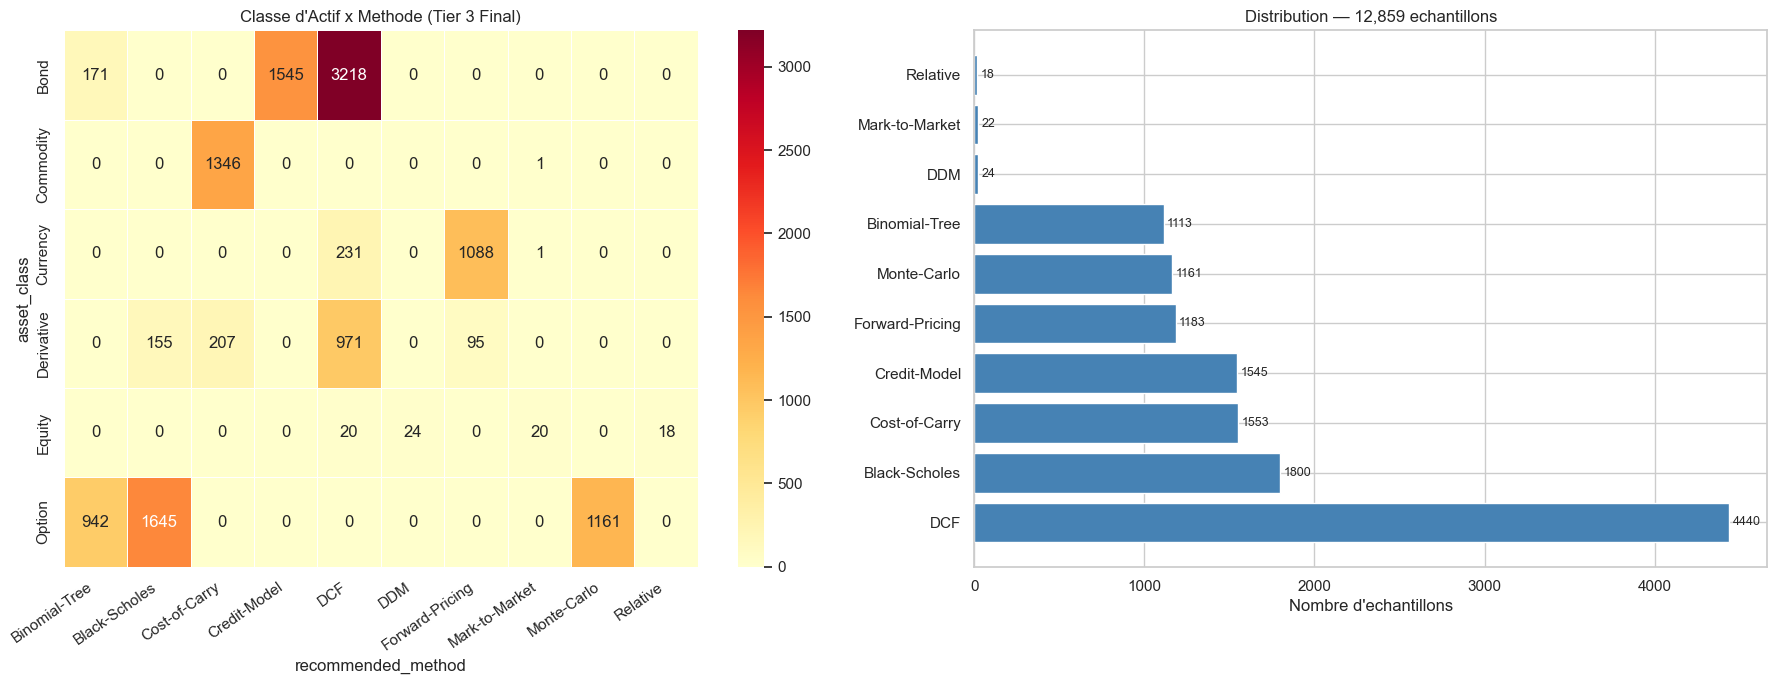

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
os.makedirs("reports/figures", exist_ok=True)

# ── Tests de cohérence ────────────────────────────────────────
v1 = ((df_final["has_early_exercise"] == 1) &
      (df_final["recommended_method"] == "Black-Scholes")).sum()
v2 = ((df_final["is_path_dependent"] == 1) &
      (df_final["recommended_method"] != "Monte-Carlo")).sum()
v3 = ((df_final["has_options_features"] == 0) &
      (df_final["recommended_method"].isin(["Black-Scholes", "Binomial-Tree", "Monte-Carlo"])) &
      (~df_final["asset_subclass"].isin(["Convertible Bond", "Swaption"]))).sum()
v4 = ((df_final["ifrs_level"] == 1) &
      (df_final["has_market_price"] == 1) &
      (df_final["liquidity"] == "High") &
      (~df_final["recommended_method"].isin(["Mark-to-Market", "Cost-of-Carry", "Forward-Pricing", "DCF", "DDM"]))).sum()

print("Verification de coherence :")
print(f"  BSM + early exercise      : {v1} violations")
print(f"  Path-dep sans MC          : {v2} violations")
print(f"  Option method sans feat   : {v3} violations")
print(f"  Level 1 liquid incoherent : {v4} violations")
total_v = v1 + v2 + v3 + v4
print(f"  Total                     : {total_v} violations")
if total_v == 0:
    print("  Toutes les regles sont respectees.")

# ── Visualisations ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ct = pd.crosstab(df_final["asset_class"], df_final["recommended_method"])
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=axes[0])
axes[0].set_title("Classe d'Actif x Methode (Tier 3 Final)")
plt.sca(axes[0])
plt.xticks(rotation=35, ha="right")

dist = df_final["recommended_method"].value_counts()
axes[1].barh(dist.index, dist.values, color="steelblue")
axes[1].set_xlabel("Nombre d'echantillons")
axes[1].set_title(f"Distribution — {len(df_final):,} echantillons")
for i, v in enumerate(dist.values):
    axes[1].text(v + 20, i, f"{v}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("reports/figures/tier3_final_validation.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Sauvegarde


In [47]:
output_csv = DATA_ROOT / "processed/labeled_valuation_dataset_tier3.csv"
output_pqt = DATA_ROOT / "processed/labeled_valuation_dataset_tier3.parquet"

df_final.to_csv(output_csv, index=False)
df_final.to_parquet(output_pqt, index=False)

print(f"CSV     : {output_csv}")
print(f"Parquet : {output_pqt}")

# Sauvegarder aussi le tableau de synthèse
summary = {
    "Source": list(sources.keys()),
    "Lignes": [len(df) if df is not None and len(df) > 0 else 0 for df in sources.values()],
}
pd.DataFrame(summary).to_csv(DATA_ROOT / "processed/tier3_sources_summary.csv", index=False)

print(f"\n{'='*60}")
print(f"  COLLECTE TIER 3 TERMINEE")
print(f"{'='*60}")
print(f"  Dataset final : {len(df_final):,} echantillons")
print(f"  Prochaine etape : 03_feature_engineering.ipynb")
print(f"  Utiliser : labeled_valuation_dataset_tier3.csv")
print(f"{'='*60}")

CSV     : data_valuation_project\processed\labeled_valuation_dataset_tier3.csv
Parquet : data_valuation_project\processed\labeled_valuation_dataset_tier3.parquet

  COLLECTE TIER 3 TERMINEE
  Dataset final : 12,859 echantillons
  Prochaine etape : 03_feature_engineering.ipynb
  Utiliser : labeled_valuation_dataset_tier3.csv
